# 13. 循环神经网络（高级篇）


Traning for 100 epochs...
 2s] Epoch 1[2560 / 13374]loss = 0.008888601651415228
 3s] Epoch 1[5120 / 13374]loss = 0.007600659737363458
 3s] Epoch 1[7680 / 13374]loss = 0.006932060901696483
 4s] Epoch 1[10240 / 13374]loss = 0.0064050831948407
 4s] Epoch 1[12800 / 13374]loss = 0.006072159055620432
evaluating trained model ...
Test set: Accuracy 4534 / 6700 67.67 %
 5s] Epoch 2[2560 / 13374]loss = 0.004272034601308405
 5s] Epoch 2[5120 / 13374]loss = 0.004088164493441582
 6s] Epoch 2[7680 / 13374]loss = 0.0039335002346585195
 6s] Epoch 2[10240 / 13374]loss = 0.0038447104278020562
 6s] Epoch 2[12800 / 13374]loss = 0.0037586573977023362
evaluating trained model ...
Test set: Accuracy 4978 / 6700 74.30 %
 7s] Epoch 3[2560 / 13374]loss = 0.003310015262104571
 7s] Epoch 3[5120 / 13374]loss = 0.0031101258122362197
 8s] Epoch 3[7680 / 13374]loss = 0.003054572230515381
 8s] Epoch 3[10240 / 13374]loss = 0.003045507421484217
 8s] Epoch 3[12800 / 13374]loss = 0.0030146099254488943
evaluating trained 

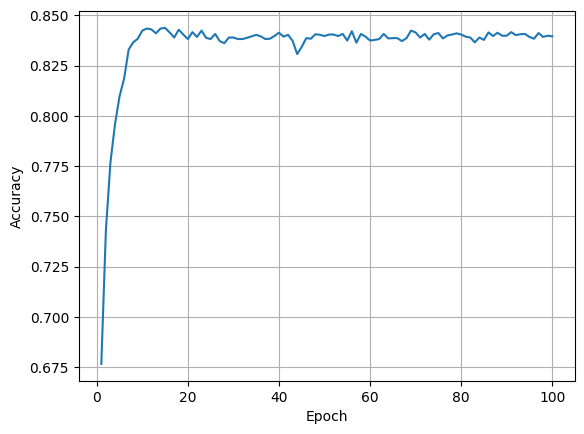

In [2]:
#加油加油加油
#认真对待每一行代码
#努力写好每一行代码
#搞懂每一行代码
 
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence
import time
import matplotlib.pyplot as plt
import numpy as np
import gzip
import csv
import math
 
"""
hidden_size=100,batch_size=256,n_layer=2,n_epochs=100,n_chars=128,
记忆体维度100，batch维度为256，层数为2层，迭代次数100次，
"""
HIDDEN_SIZE = 100
BATCH_SIZE = 256
N_LAYER = 2
N_EPOCHS = 100
N_CHARS = 128
USE_GPU = True
 
 
class NameDataset(Dataset):
    """
    NameDataset类继承Dataset类
    重写__init__,__getitem__,__len__方法
    定义getCountryDict,idx2country,getCountriesNum函数
    实例化后，返回的有：
    countries:list,数据中的第二列即所有国家，无排序，无去重
    country_dict:dict:18,数据中所有国家，有排序，有去重，{键；键值}
    country_list:list:18,数据中所有国家，有排序，有去重
    country_num:int:18
    len:int,数据中名字的长度，即所有数据的数量
    names:list,数据所有名字，有排序
    """
    def __init__(self, is_train_set=True):
        """
        这个文件是第一列为名字，第二列为国家
        :param is_train_set: 用于判断文件类型
        使用gzip方法读取文件（解压读取）
            再用csv的方法将提取的文件读取，
            再用list方法将数据转换成列表 -- rows
        name = 取出rows列表中每个元素的第一个值；即文件的第一列 -- 名字
        len = 多少个名字
        counties = 取出rows列表中每个元素的第二个值，即文件的第二列 -- 国家
        set：去重，无序。将contries列表中的国家去重，随机存放  -- 假设返回 - A 列表
        将A列表进行排序，从小到大，按首字母再其次俺第二个字母（可以根据ASCII码）-返回列表 -- country_list
        country_dict = 调用getCountryDict函数  将列表转换为字典
        country_num = 取出country_list的长度，返回国家有多少个
        """
        filename = 'names_train.csv.gz' if is_train_set else 'names_test.csv.gz'
        with gzip.open(filename, 'rt') as f:
            reader = csv.reader(f)
            rows = list(reader)
        self.names = [row[0] for row in rows]
        self.len = len(self.names)
        self.countries = [row[1] for row in rows]
        self.country_list = list(sorted(set(self.countries)))
        self.country_dict = self.getCountryDict()
        self.country_num = len(self.country_list)
 
    def __getitem__(self, index):
        """
        :param index:
        :return: 返回名字的索引，国家从小到大的索引位置，对应字典中的位置
        """
 
        return self.names[index], self.country_dict[self.countries[index]]
 
    def __len__(self):
        """
        :return: 求长度
        """
 
        return self.len
 
    def getCountryDict(self):
        """
        创建一个空字典 -- country_dict
        for循环，取出当前循环次数，和当前循环的名字
        存放字典，对应索引，
        :return:将列表转换为字典。（键，键值）
        """
        country_dict = dict()
        for idx, country_name in enumerate(self.country_list, 0):
            country_dict[country_name] = idx
 
        return country_dict
 
    def idx2country(self, index):
        """
        返回country_list的值
        """
 
        return self.country_list[index]
 
    def getCountriesNum(self):
        """
        :return: 国家的数量
        """
 
        return self.country_num
 
 
"""
实例化NameDataset类 -- trainset
利用DataLoader函数对数据进行处理，batch_size个数据为一组，shuffle打乱数据 -- trainloader
实例化NameDataset类 -- testset
利用DataLoader函数对数据进行处理，batch_size个数据为一组，shuffle不打乱数据 -- testloader
返回国家的数量（调用NameDataset类）
"""
trainset = NameDataset(is_train_set=True)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testset = NameDataset(is_train_set=False)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)
N_COUNTRY = trainset.getCountriesNum()
 
"""
^^^^^数据的处理阶段^^^^^
"""
 
def create_tensor(tensor):
    """
    传入张量
    判断USE_GPU:
    将数据传到cuda上
    """
    if USE_GPU:
        device = torch.device("cuda:0")
        tensor = tensor.to(device)
 
    return tensor
 
 
class RNNClassifier(torch.nn.Module):
    """
    RNNClassifier继承Module类
    重写__init__,_init_hidden,forward,方法。
    """
    def __init__(self, input_size, hidden_size, output_size, n_layers=1, bidirectional=True):
        """
        super超类
        :param input_size:输入数据维度
        :param hidden_size:记忆体维度
        :param output_size:输出数据维度
        :param n_layers:层数
        :param bidirectional:判断是双向还是单向传播
        Embedding:嵌入层，先对输入数据做一个预处理，从input_size维度到hidden维度
        GRU模型，hidden_size:,hidden_size:,n_layers:,
        fc:Linear:线性模型:hidden_size * n_directions(输入模型维度),输出模型维度
        """
        super(RNNClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        self.n_directions = 2 if bidirectional else 1
        self.embedding = torch.nn.Embedding(input_size, hidden_size)
        self.gru = torch.nn.GRU(hidden_size, hidden_size, n_layers,
                                bidirectional=bidirectional)
        self.fc = torch.nn.Linear(hidden_size * self.n_directions, output_size)
 
    def _init_hidden(self, batch_size):
        """
        搭建记忆体的维度（self.n_layers * self.n_directions，batch_size,hidden_size）
        返回：记忆体传到模型GPU上
        """
        hidden = torch.zeros(self.n_layers * self.n_directions,
                             batch_size, self.hidden_size)
 
        return create_tensor(hidden)
 
    def forward(self, input, seq_lengths):
        """
        数据流程
        batch_size = 输入数据的宽度，
        hidden的维度调用_init_hidden方法
        将数据进行embedding层；
        使用pack_padded_sequence函数得到 - gru_input
        将处理好的数据传入gru模型函数中返回 -- output,hidden
        判断是单向还是双向传播
        最后将记忆层进行星星层变换得到输出的结果，并返回
        forward:输入数据，时间长度
        :param input:输入数据
        :param seq_lengths:时间序列
        :return:对记忆体的参数进行fc全连接变换，输出，即out
        """
        #input shape: B x S --> S x B  转置
        input = input.t()
        batch_size = input.size(1)
 
        hidden = self._init_hidden(batch_size)
        embedding = self.embedding(input)
 
        #pack them up
        gru_input = pack_padded_sequence(embedding, seq_lengths)
 
        output, hidden = self.gru(gru_input, hidden)
        if self.n_directions == 2:
            hidden_cat = torch.cat([hidden[-1], hidden[-2]], dim=1)
        else:
            hidden_cat = hidden[-1]
        fc_output = self.fc(hidden_cat)
 
        return fc_output
 
 
def name2list(name):
    """
    :param name: 名字
    :return: 名字，长度
    """
    arr = [ord(c) for c in name]
 
    return arr, len(arr)
 
 
def make_tensors(names, countries):
    """
    for循环，调用name2list函数，传参数给--sequences_and_lengths
    取出名字
    取出长度，变成张量
    创建全是0.的维度为（len(name_sequences),seq_lengths.max()），并变为长整型 -- 行：名字数，列：最长的ascii名字
    遍历，并返回，最后构建seq_tensor[idx,:seq_len]的矩阵，  --- zip() 函数用于将可迭代的对象作为参数，将对象中对应的元素打包成一个个元组，然后返回由这些元组组成的列表。
    排序，依据序列长度降序
    """
    sequences_and_lengths = [name2list(name) for name in names]
    name_sequences = [s1[0] for s1 in sequences_and_lengths]
    seq_lengths = torch.LongTensor([s1[1] for s1 in sequences_and_lengths])
 
    #make rensor of name, BatchSize x SeqLen
    seq_tensor = torch.zeros(len(name_sequences), seq_lengths.max()).long()
    for idx, (seq, seq_len) in enumerate(zip(name_sequences, seq_lengths), 0):
        seq_tensor[idx, :seq_len] = torch.LongTensor(seq)
 
    #sort by length to use pack_padded_sequence
    seq_lengths, perm_idx = seq_lengths.sort(dim=0, descending=True)
    seq_tensor = seq_tensor[perm_idx]
    countries = countries[perm_idx]
 
    return create_tensor(seq_tensor), \
        seq_lengths, \
        create_tensor(countries)
 
 
def time_since(since):
    """
    时间计时模块
    """
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
 
    return '%dm %ds' % (m, s)
 
 
def trainModel():
    """
    loss初始为0在循环之外；
    将训练集传入，取出数据，生成输入数据，长度，标签
    放入classifier模型训练
    利用criterion函数计算损失值
    梯度归零
    反向传播
    优化器迭代，更新参数（权重，偏置）
    损失值累加
    输出
    :return:所有数据一次的损失
    """
    total_loss = 0
    for i, (names, countries) in enumerate(trainloader, 1):
        inputs, seq_lengths, target = make_tensors(names, countries)
        output = classifier(inputs, seq_lengths)
        loss = criterion(output, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        total_loss += loss.item()
        if i % 10 == 0:
            print(f'[{time_since(start)}] Epoch {epoch}', end='')
            print(f'[{i * len(inputs)} / {len(trainset)}]', end='')
            print(f'loss = {total_loss / (i * len(inputs))}')
 
    return total_loss
 
 
def testModel():
    """
    测试集
    不用计算梯度
    取出数据
    将特征放入，计算预测值
    求预测数据中的最大值，dim=1--每一行
    损失累加
    输出
    :return:错误率
    """
    correct = 0
    total = len(testset)
    print("evaluating trained model ...")
    with torch.no_grad():
        for i, (names, countries) in enumerate(testloader, 1):
            inputs, seq_lengths, target = make_tensors(names, countries)
            output = classifier(inputs, seq_lengths)
            pred = output.max(dim=1, keepdim=True)[1]
            correct += pred.eq(target.view_as(pred)).sum().item()
 
        percent = '%.2f' % (100 * correct / total)
        print(f'Test set: Accuracy {correct} / {total} {percent} %')
 
    return correct / total
 
 
if __name__ == '__main__':
    """
    模型RNNClassifier
    GPU运行
    损失函数criterion
    优化器Adam：初始化模型参数
    记录时间
    输出：一共输出多少次
    创建一个列表
        for循环对N_EPOCHS（1 - n_epochs+1）
        跑训练模型
        跑测试模型 -- acc
        将返回值依次存放在acc_list[]列表中
    画图部分
    x轴为acc_list的长度，间距为1
    y轴为acc_list的数值
    """
    classifier = RNNClassifier(N_CHARS, HIDDEN_SIZE, N_COUNTRY, N_LAYER)
    if USE_GPU:
        device = torch.device("cuda:0")
        classifier.to(device)
 
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)
 
    start = time.time()
    print("Traning for %d epochs..." % N_EPOCHS)
    acc_list = []
    for epoch in range(1, N_EPOCHS + 1):
        #Train cycle
        trainModel()
        acc = testModel()
        acc_list.append(acc)
 
epoch = np.arange(1, len(acc_list) + 1, 1)
acc_list = np.array(acc_list)
plt.plot(epoch, acc_list)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.show()